In [1]:
import sys, os
from utils import * 


In [2]:
import joblib

DATASET_NAME, X_train, X_test, y_train, y_test = joblib.load("ULB_data.pkl")
y_test = y_test.values.ravel()

MODEL_NAME = "Isolation_Forest"
DE_LONG_RESULTS = "ULB_all_results.pkl"
METRICS = "ULB_metrics.pkl"


In [3]:
# ===============================================================
# ===============================================================
# ===============================================================
# ===============================================================
# ===============================================================
# ===================== 2. Isolation Forest =====================
# ===============================================================
# ===============================================================
# ===============================================================
# ===============================================================
# ===============================================================

In [7]:
# ===================== Fit Isolation Forest =====================
iso_train_scores, iso_test_scores, iso_model = run_isolation_forest(X_train, X_test)


In [8]:
# ===================== Store metrics =====================
iso_metrics = store_anomaly_metrics(y_true=y_test, scores=iso_test_scores, dataset_name=DATASET_NAME, model_name=MODEL_NAME)
display(iso_metrics)


,Model,Data,Precision,Precision_CI,Recall,Recall_CI,F1,F1_CI,ROC_AUC,ROC_AUC_CI,PR_AUC,PR_AUC_CI,Confusion_Matrix,Threshold
0,Isolation_Forest,creditcard,0.005616,0.003-0.008,0.163265,0.099-0.238,0.010859,0.006-0.016,0.642132,0.585-0.697,0.004348,0.003-0.007,"[[54031, 2833], [82, 16]]",0.07242


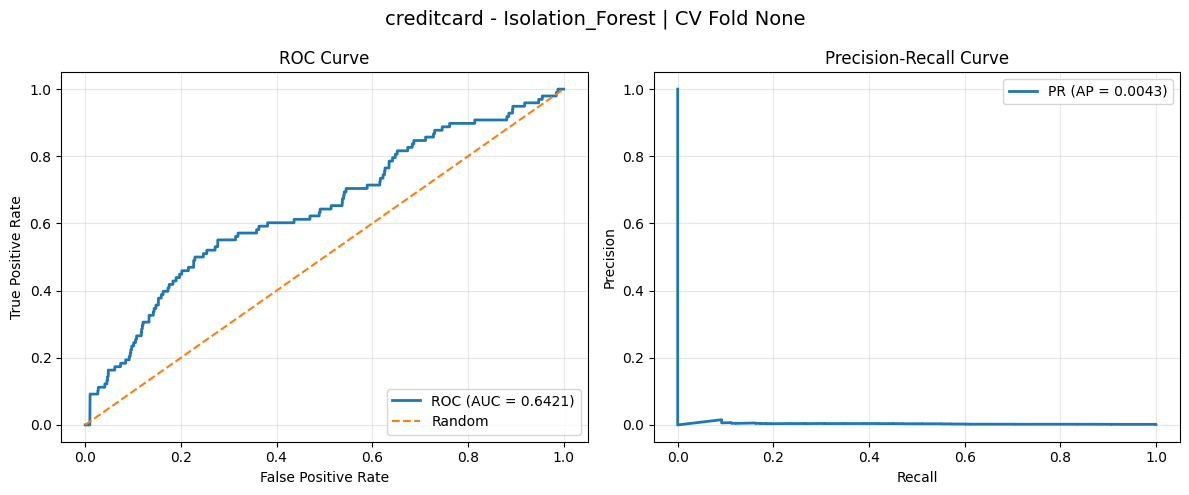

In [9]:
# ===================== Plot results =====================
plot_anomaly_roc_pr(y_true=y_test, scores=iso_test_scores, dataset_name=DATASET_NAME, model_name=MODEL_NAME)


In [4]:
# ===================== Fit on CV folds =====================

iso_cv_results = fit_cross_validate(X_train, y_train, X_test, y_test, run_isolation_forest, DATASET_NAME, MODEL_NAME, CV_FOLDS, RANDOM_STATE)


In [5]:
# ===================== Store CV metrics =====================
iso_cv_metrics = pd.concat([r["test_metrics"] for r in iso_cv_results], ignore_index=True)
display(iso_cv_metrics)


,Model,Data,Precision,Precision_CI,Recall,Recall_CI,F1,F1_CI,ROC_AUC,ROC_AUC_CI,PR_AUC,PR_AUC_CI,Confusion_Matrix,Threshold
0,Isolation_Forest_Fold1,creditcard,0.005616,0.003-0.008,0.163265,0.099-0.238,0.010859,0.006-0.016,0.631157,0.572-0.690,0.004363,0.003-0.007,"[[54031, 2833], [82, 16]]",0.071028
1,Isolation_Forest_Fold2,creditcard,0.005616,0.003-0.009,0.163265,0.097-0.241,0.010859,0.006-0.016,0.648092,0.588-0.706,0.020657,0.007-0.047,"[[54031, 2833], [82, 16]]",0.069813
2,Isolation_Forest_Fold3,creditcard,0.006318,0.004-0.009,0.183673,0.111-0.261,0.012216,0.007-0.018,0.653608,0.596-0.710,0.010739,0.004-0.024,"[[54033, 2831], [80, 18]]",0.069048
3,Isolation_Forest_Fold4,creditcard,0.005967,0.003-0.009,0.173469,0.104-0.253,0.011537,0.007-0.017,0.640828,0.582-0.700,0.005687,0.003-0.011,"[[54032, 2832], [81, 17]]",0.067416
4,Isolation_Forest_Fold5,creditcard,0.005967,0.003-0.009,0.173469,0.103-0.255,0.011537,0.007-0.017,0.641832,0.583-0.699,0.017688,0.006-0.041,"[[54032, 2832], [81, 17]]",0.065111


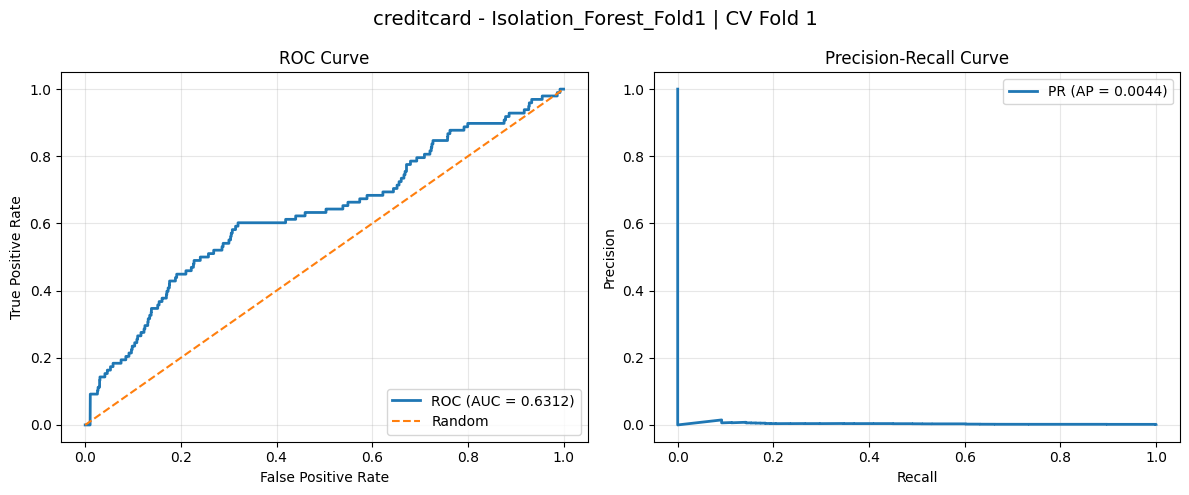

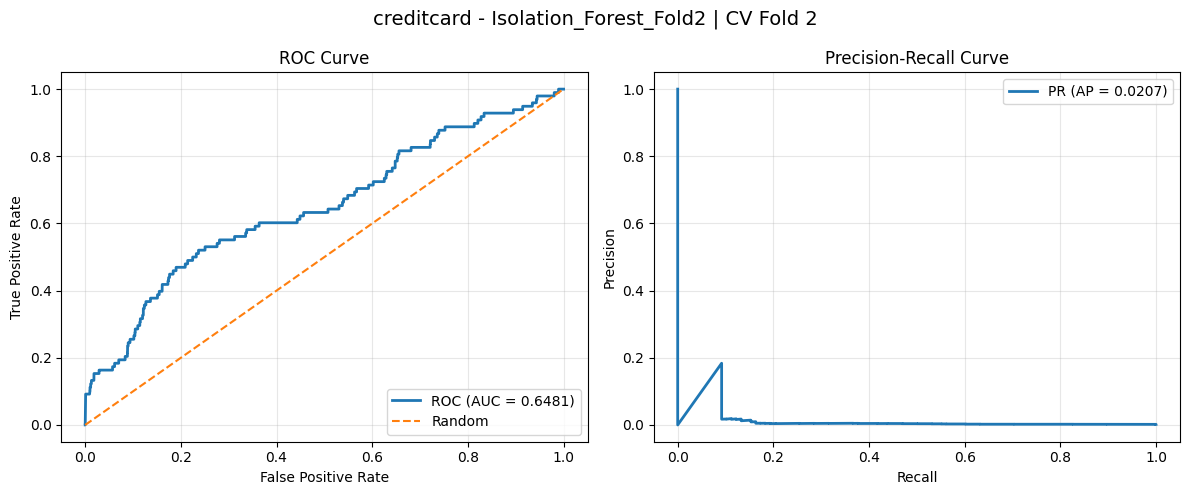

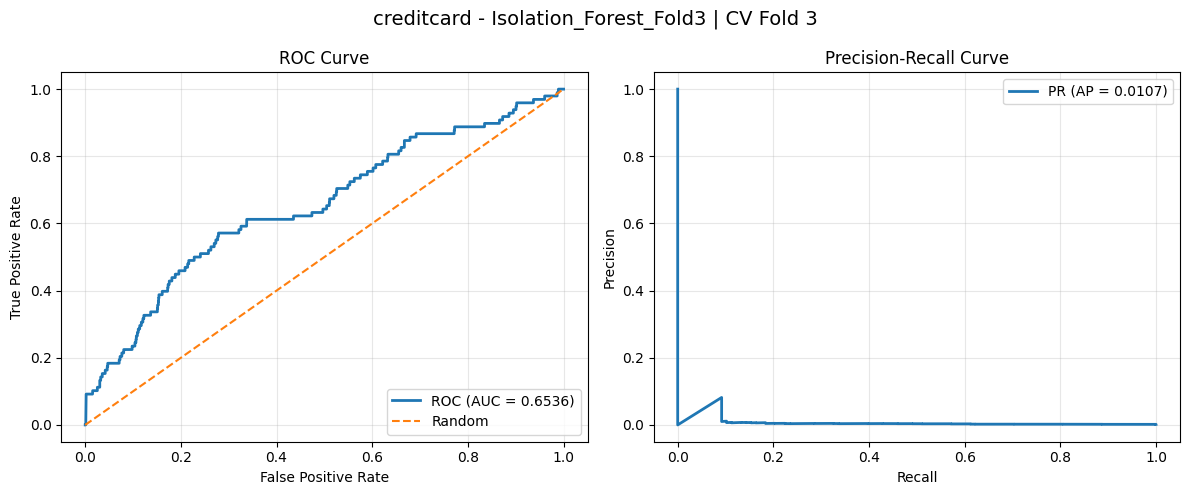

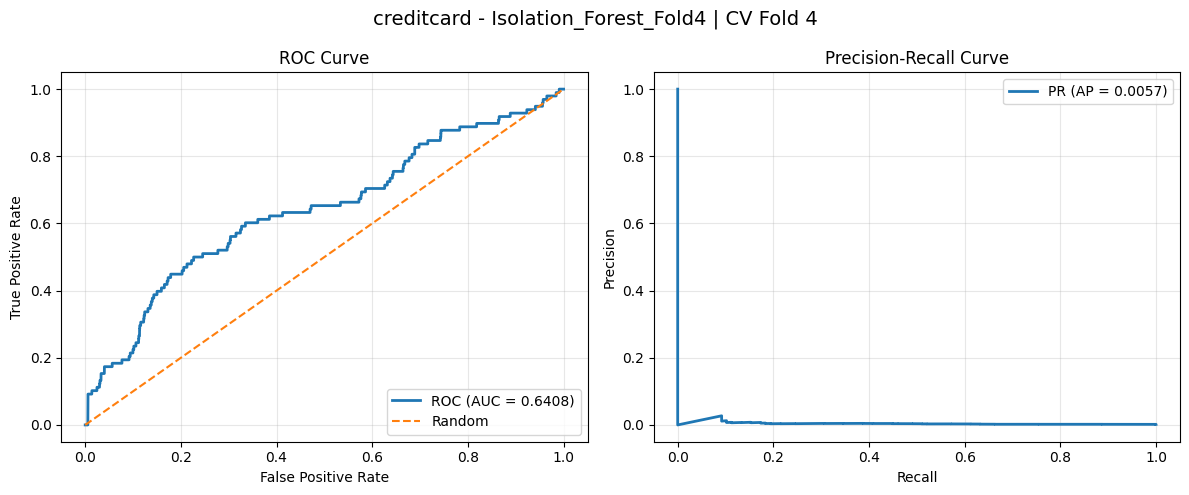

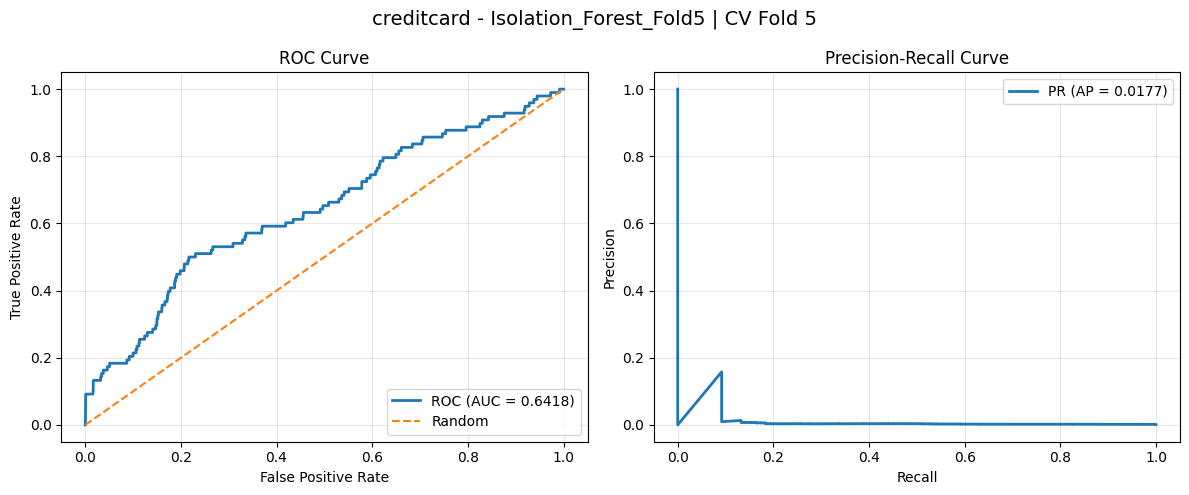

In [6]:
# ===================== Plot CV results =====================

for r in iso_cv_results:
    plot_anomaly_roc_pr(y_test, r["test_scores"], DATASET_NAME, f"{MODEL_NAME}_Fold{r['fold']}", r["fold"])


In [10]:
if os.path.exists(DE_LONG_RESULTS):
    results = joblib.load(DE_LONG_RESULTS)
else:
    results = {}

results[MODEL_NAME] = {
    "test_scores": iso_test_scores,
    "auc": roc_auc_score(y_test, iso_test_scores)
}

joblib.dump(results, DE_LONG_RESULTS)

['ULB_all_results.pkl']

In [11]:
if os.path.exists(METRICS):
    results = joblib.load(METRICS)
else:
    results = {}

results[MODEL_NAME] = {
    "metrics": iso_metrics,
    "cv_metrics": iso_cv_results
}

joblib.dump(results, METRICS)

['ULB_metrics.pkl']